In [17]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
results = pd.DataFrame([

    {
        'Sector':'Healthcare',
        'Model':'Logistic Regression',
        'Accuracy':0.6000,
        'Precision':0.7446,
        'Recall':0.6300,
        'F1':0.6825,
        'ROC_AUC':0.6213
    },

    {
        'Sector':'Healthcare',
        'Model':'Random Forest',
        'Accuracy':0.6450,
        'Precision':0.7331,
        'Recall':0.7546,
        'F1':0.7437,
        'ROC_AUC':0.6340
    },

    {
        'Sector':'Healthcare',
        'Model':'XGBoost',
        'Accuracy':0.6500,
        'Precision':0.7209,
        'Recall':0.7949,
        'F1':0.7561,
        'ROC_AUC':0.6417
    }

])

results

,Sector,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Healthcare,Logistic Regression,0.600,0.7446,0.6300,0.6825,0.6213
1,Healthcare,Random Forest,0.645,0.7331,0.7546,0.7437,0.6340
2,Healthcare,XGBoost,0.650,0.7209,0.7949,0.7561,0.6417


In [20]:
import os

os.makedirs(
    'outputs/results',
    exist_ok=True
)

results.to_csv(
    'outputs/results/healthcare_all_results.csv',
    index=False
)

print(
    "Healthcare results saved successfully."
)

Healthcare results saved successfully.


In [21]:
print("Healthcare Model Comparison")
print("="*70)

print(
    results.to_string(index=False)
)

Healthcare Model Comparison
    Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
Healthcare Logistic Regression     0.600     0.7446  0.6300 0.6825   0.6213
Healthcare       Random Forest     0.645     0.7331  0.7546 0.7437   0.6340
Healthcare             XGBoost     0.650     0.7209  0.7949 0.7561   0.6417


In [22]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC_AUC'
]

print("Best model per metric")
print("-"*40)

for metric in metrics:

    best_value = results[metric].max()

    best_models = results[
        results[metric] == best_value
    ]['Model'].tolist()

    print(
        f"{metric}: "
        f"{', '.join(best_models)} "
        f"({best_value:.4f})"
    )

Best model per metric
----------------------------------------
Accuracy: XGBoost (0.6500)
Precision: Logistic Regression (0.7446)
Recall: XGBoost (0.7949)
F1: XGBoost (0.7561)
ROC_AUC: XGBoost (0.6417)


In [23]:
import os

os.makedirs(
    'outputs/plots/healthcare',
    exist_ok=True
)

os.makedirs(
    'outputs/results',
    exist_ok=True
)

print("Folders created successfully.")

Folders created successfully.


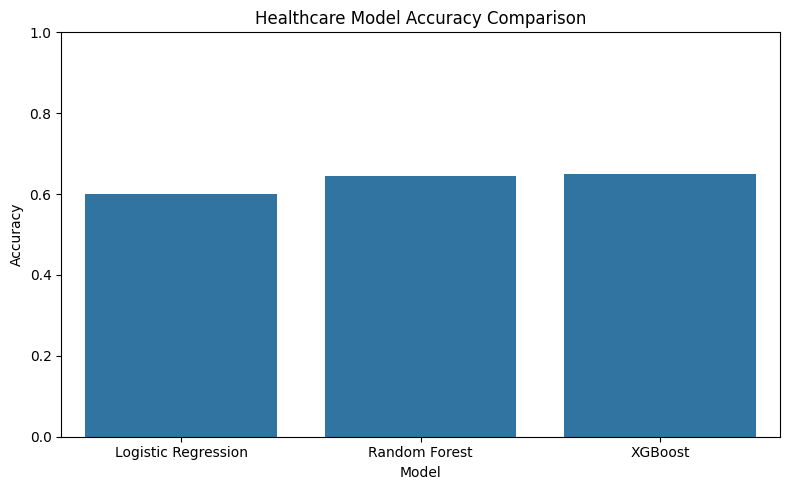

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title(
    'Healthcare Model Accuracy Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/healthcare/accuracy_comparison.png',
    bbox_inches='tight'
)

plt.show()

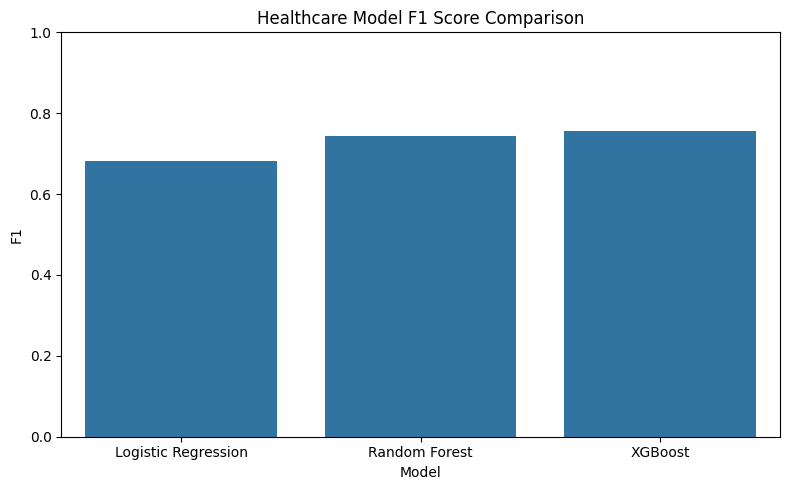

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='F1'
)

plt.title(
    'Healthcare Model F1 Score Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/healthcare/f1_comparison.png',
    bbox_inches='tight'
)

plt.show()

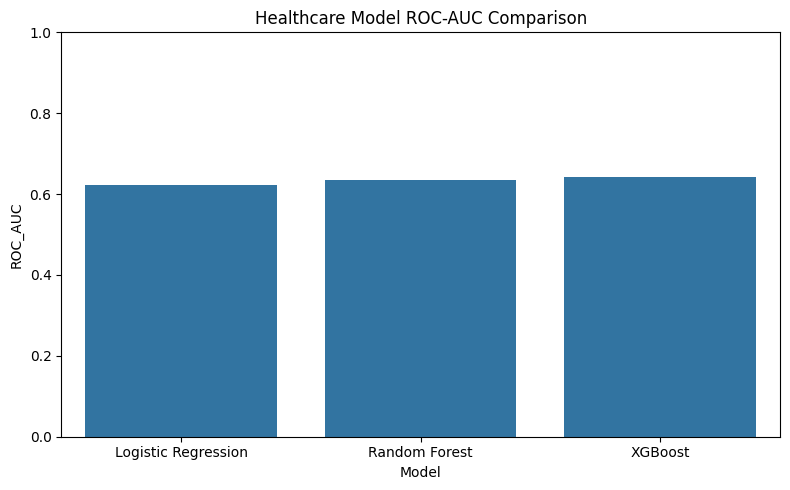

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='ROC_AUC'
)

plt.title(
    'Healthcare Model ROC-AUC Comparison'
)

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    'outputs/plots/healthcare/roc_auc_comparison.png',
    bbox_inches='tight'
)

plt.show()

In [27]:
metrics_df = results.melt(

    id_vars='Model',

    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ],

    var_name='Metric',

    value_name='Score'
)

metrics_df.head()

,Model,Metric,Score
0,Logistic Regression,Accuracy,0.6000
1,Random Forest,Accuracy,0.6450
2,XGBoost,Accuracy,0.6500
3,Logistic Regression,Precision,0.7446
4,Random Forest,Precision,0.7331


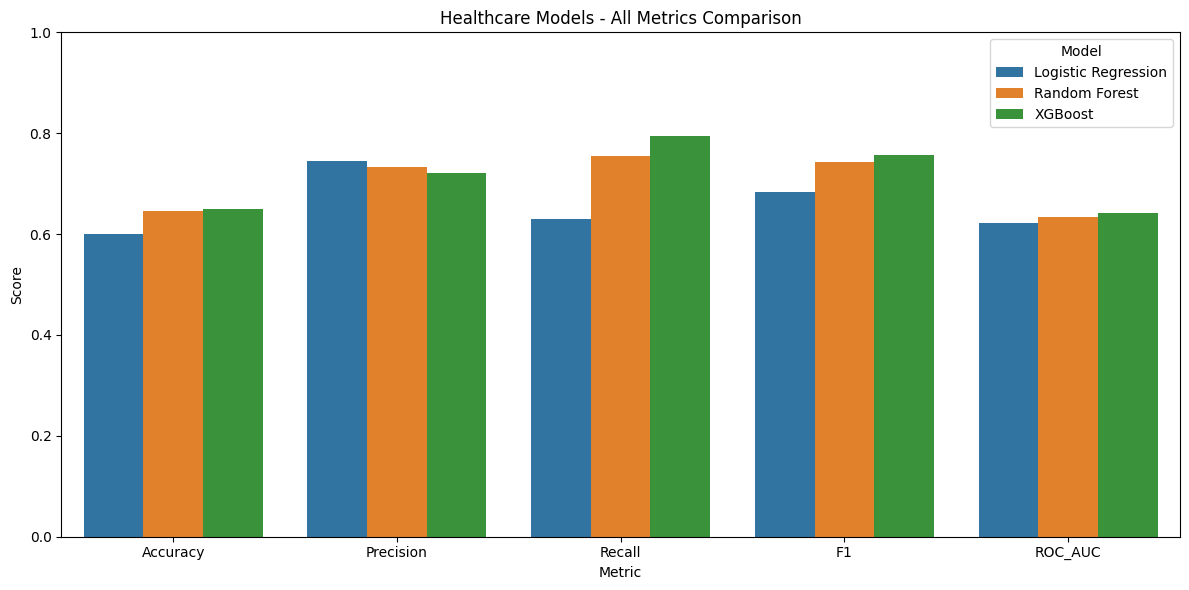

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=metrics_df,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title(
    'Healthcare Models - All Metrics Comparison'
)

plt.ylim(0,1)

plt.legend(
    title='Model'
)

plt.tight_layout()

plt.savefig(
    'outputs/plots/healthcare/all_metrics_comparison.png',
    bbox_inches='tight'
)

plt.show()

In [29]:
results['Average_Score'] = results[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
].mean(axis=1)

ranking = results.sort_values(
    by='Average_Score',
    ascending=False
)

print("Overall Ranking")
print("="*40)

print(
    ranking[
        ['Model','Average_Score']
    ]
)

Overall Ranking
                 Model  Average_Score
2              XGBoost        0.71272
1        Random Forest        0.70208
0  Logistic Regression        0.65568


In [30]:
best_model = ranking.iloc[0]['Model']

print("="*60)
print("FINAL HEALTHCARE CONCLUSION")
print("="*60)

print(
    f"Best Performing Model: {best_model}"
)

print(
    f"Average Score: "
    f"{ranking.iloc[0]['Average_Score']:.4f}"
)

print(
    "\nHealthcare churn appears to be "
    "driven by multiple behavioural, "
    "satisfaction and financial factors."
)

print(
    "\nXGBoost achieved the best overall "
    "performance and is selected as the "
    "recommended model for healthcare "
    "churn prediction."
)

FINAL HEALTHCARE CONCLUSION
Best Performing Model: XGBoost
Average Score: 0.7127

Healthcare churn appears to be driven by multiple behavioural, satisfaction and financial factors.

XGBoost achieved the best overall performance and is selected as the recommended model for healthcare churn prediction.


In [31]:
df = pd.read_csv(
    'data/healthcare/healthcare_new_patients.csv'
)

print(df.head())
print(df.shape)

  PatientID  Age  Gender State  Tenure_Months          Specialty  \
0     HC001   65  Female    CA             12         Cardiology   
1     HC002   42    Male    TX             84   General Practice   
2     HC003   58  Female    FL             18  Internal Medicine   
3     HC004   35    Male    NY             96         Pediatrics   
4     HC005   50  Female    GA             24         Cardiology   

  Insurance_Type  Visits_Last_Year  Missed_Appointments  \
0       Medicaid                 2                    5   
1        Private                14                    0   
2       Medicare                 3                    4   
3        Private                16                    0   
4       Self-Pay                 4                    3   

   Days_Since_Last_Visit Last_Interaction_Date  Overall_Satisfaction  \
0                    420            2024-04-15                   1.8   
1                     20            2025-05-10                   4.8   
2                   

In [32]:
print(df.columns.tolist())

['PatientID', 'Age', 'Gender', 'State', 'Tenure_Months', 'Specialty', 'Insurance_Type', 'Visits_Last_Year', 'Missed_Appointments', 'Days_Since_Last_Visit', 'Last_Interaction_Date', 'Overall_Satisfaction', 'Wait_Time_Satisfaction', 'Staff_Satisfaction', 'Provider_Rating', 'Avg_Out_Of_Pocket_Cost', 'Billing_Issues', 'Portal_Usage', 'Referrals_Made', 'Distance_To_Facility_Miles']
